# Tutorial: Signal Synthesis and Spectral Reconstruction with WaveSpec

## Overview
This tutorial demonstrates how to use the `WaveSpec.Signal` module to:
1. **Generate** a synthetic time-domain signal from a discrete frequency spectrum
2. **Reconstruct** the power spectral density (PSD) from the simulated signal using FFT
3. **Validate** that the reconstructed spectrum matches the target model

### Workflow
The complete workflow follows this cycle:
- **Target Model:** Define a continuous spectrum model (e.g., JONSWAP) with parameters `Hs` (significant wave height) and `Tp` (peak period)
- **Discretization:** Sample the spectrum into discrete frequency components with amplitudes
- **Synthesis:** Generate a time-domain signal by superposing all harmonic components
- **Analysis:** Compute the single-sided power spectral density from the time series using FFT
- **Smoothing:** Apply averaging to reduce FFT noise and match the original spectrum
- **Validation:** Test that energy, peak frequency, and spectral structure are preserved

This approach is fundamental to ocean wave simulation: we specify a statistical (spectral) model, generate a realization as a time series, and verify that its FFT recovers the input spectrum.

In [1]:
using WaveSpec       
using Test           
using Plots          

┌ Info: WaveSpec initialized: Ready for spectral sea state synthesis.
└ @ WaveSpec /home/elmanyer/Documents/TU-Delft/WaveSpec.jl/src/WaveSpec.jl:33


## Step 1: Define a Target Spectrum Model
We start by defining the target continuous spectrum that will drive our simulation. Choose parameters and spectrum type (JONSWAP, Bretschneider, etc.). The discretization will sample this continuous model into components.

**Key parameters:**
- `Hs`: Significant wave height (m) — a measure of typical wave amplitude
- `Tp`: Peak period (s) — period corresponding to maximum spectral energy
- `h`: Water depth (m) — used to resolve the dispersion relation for wavenumbers
- `nf`: Number of discrete frequency samples — higher values capture finer spectral structure

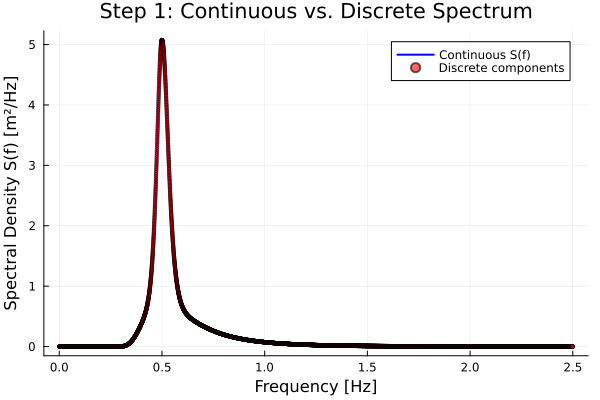

In [ ]:
using WaveSpec.ContinuousSpectrums
using WaveSpec.SpectralSampling
using WaveSpec.SpectralSpreading

# --- Step 1a: Set Target Wave Parameters ---
Hs_target = 3.0        # Significant wave height [m]
Tp_target = 2.0        # Peak period [s]
h_target  = 30.0       # Water depth [m]

# (Alternative parameters for other spectrum types)
Hs_target_2 = 1.0      # Secondary swell significant height [m]
Tp_target_2 = 4.0      # Secondary swell peak period [s]
λ1 = 2                 # Primary swell partition weight
λ2 = 3                 # Secondary swell partition weight

# --- Step 1b: Select Continuous Spectrum Model ---
# Each spectrum encodes the energy distribution S(f) across frequencies
spec = JONSWAP(Hs_target, Tp_target)                                      # Unimodal spectrum
# spec = Bretschneider(Hs_target, Tp_target)                             # Alternative model
# spec = OchiHubble(Hs_target, Tp_target, λ1, Hs_target_2, Tp_target_2, λ2)  # Bimodal spectrum

# --- Step 1c: Discretize the Spectrum ---
nf = 2^13              # Number of discrete frequency samples (8192 components)

# Create discrete spectrum by sampling the continuous model uniformly in frequency domain
# FrequencyDomain means samples are equally spaced in Hz; UniformSampling() is the strategy
ds = DiscreteSpectralSpreading(spec, UniformSampling(), 
                               get_fmin(spec), get_fmax(spec), nf; 
                               domain=FrequencyDomain(), mess=false)

# --- Step 1d: Visualize Discretization ---
# Evaluate continuous spectrum at fine grid for reference
f_cont = range(get_fmin(spec), get_fmax(spec), length=1000)
S_cont = [ContinuousSpectrums.get_density(spec, f) for f in f_cont]

p1 = plot(f_cont, S_cont, label="Continuous S(f)", lw=2, color=:blue)

# Extract and plot discrete spectrum components
# Relation: A_i = sqrt(2*S(f_i)*Δf), so S(f_i) ≈ A_i^2 / (2*Δf)
freqs = get_frequencies(ds)              # Discrete frequency samples [Hz]
amplitudes = get_amplitudes(ds)          # Wave component amplitudes at spectral bin centers [m]
df_ds = freqs[2] - freqs[1]              # Spectral bin width [Hz]
S_discrete = (amplitudes.^2 ./ 2.0) ./ df_ds   # Discrete spectral density [m²/Hz]

scatter!(freqs, S_discrete, label="Discrete components", markersize=2, alpha=0.6, color=:red)
title!("Step 1: Continuous vs. Discrete Spectrum")
xlabel!("Frequency [Hz]")
ylabel!("Spectral Density S(f) [m²/Hz]")

## Step 2: Synthesize Time-Domain Signal
Now we generate a time-domain signal by superposing all harmonic components from the discrete spectrum, following the Airy wave theory. In this case, where the sea is simply characterised by the discrete spectrum `ds`, each component yields:
- **Amplitude** $A_i$ derived from spectral energy in frequency band $i$
- **Angular frequency** $\omega_i = 2\pi f_i$
- **Random phase** $\phi_i$ ∈ [0, 2π) for stochasticity
- **Wavenumber** $k_i$ from the dispersion relation (depends on depth `h`)

and the surface elevation is synthesized as:
$$\eta(t) = \sum_{i=1}^{N_f} A_i \cos(\omega_i t + \phi_i)$$

However, if instead a complete `AiryState` is provided, the signal will be generated according to the characteristics of that state.

The `generate_signal()` function handles all these details internally and returns a time vector and the corresponding signal values. By default, the signal returned corresponds to the surface elevation $\eta$, however this can be changed to any other Airy sea profile ($\eta$, $u$, $v$ or $w$).

Furthermore, by default the signal is evaluated at the origin of coordinates ($x =y=z=0$), but this can also be changed. For more details see module `Signal`.

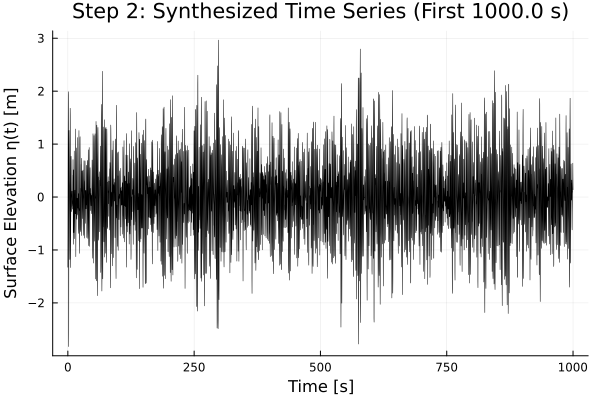

In [3]:
using WaveSpec.Signal

# Generate a long time series from the discrete spectrum
N = 2^14               # Total number of time samples (16384 samples)
t, signal = generate_signal(ds, h_target, N)

# The time vector t spans from 0 to T_total (determined by N and sampling rate)
# signal η(t) is a 1D array of surface elevation values at each time step

# Plot a manageable subset for visualization
T_window = 1000.0      # Time window to display [s]
time_mask = t .<= T_window
p2 = plot(t[time_mask], signal[time_mask], 
          color=:black, lw=0.5, legend=false)
title!("Step 2: Synthesized Time Series (First " * string(T_window) * " s)")
xlabel!("Time [s]")
ylabel!("Surface Elevation η(t) [m]")

## Step 3: Reconstruct Power Spectral Density via FFT
We compute the discrete Fourier transform (DFT) of the time series to recover the frequency-domain representation. The process:

1. **Sampling Rate:** Set $f_s = 2 f_{max}$ to satisfy the Nyquist criterion and avoid aliasing
2. **FFT:** Compute the DFT, which yields the complex amplitude at each frequency
3. **Single-Sided PSD:** Convert to power spectral density via $S(f) = |X(f)|^2 / (f_s \cdot N)$

The result is a noisy estimate of the target spectrum. Noise arises because:
- Finite record length: only $N$ samples, not infinite
- Finite frequency resolution: $\Delta f = f_s / N$
- FFT windowing effects and spectral leakage

Despite noise, the overall structure and peak should match the target model.

Sample Length = 16384
Least count Hz = 0.00030517578125
Max Freq (Half band) Hz = 2.5


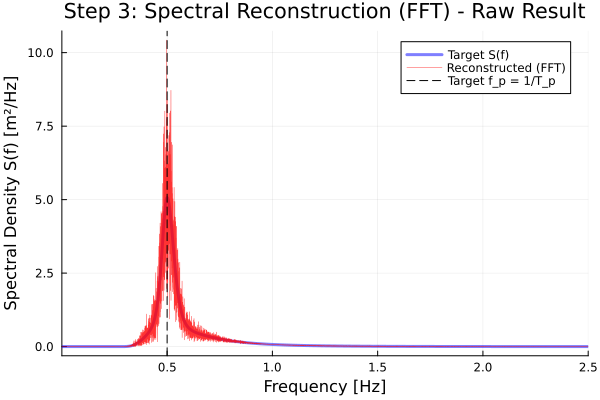

In [4]:
# Set sampling rate to satisfy Nyquist criterion: f_s ≥ 2*f_max
fs = 2.0 * get_fmax(spec)  # Sampling frequency [Hz]

# Compute the single-sided power spectral density via FFT
# fHalf:  Positive frequencies [Hz] up to Nyquist
# fAmp:   (Not used here; complex amplitudes)
# psd:    Power spectral density S(f) [m²/Hz], one-sided
fHalf, fAmp, psd = get_single_sided_spectrum(signal, fs)

# Overlay the reconstructed FFT spectrum with the target continuous spectrum
p3 = plot(f_cont, S_cont, label="Target S(f)", lw=3, color=:blue, alpha=0.5)
plot!(fHalf, psd, label="Reconstructed (FFT)", color=:red, lw=0.5, alpha=0.8)
title!("Step 3: Spectral Reconstruction (FFT) - Raw Result")
xlabel!("Frequency [Hz]")
ylabel!("Spectral Density S(f) [m²/Hz]")
xlims!(get_fmin(spec), get_fmax(spec))

# Mark the peak frequency for reference
fp_target = 1.0 / get_Tp(spec)
vline!([fp_target], label="Target f_p = 1/T_p", line=:dash, color=:black)

## Step 4: Smooth the FFT to Reduce Noise
The raw FFT output is noisy due to:
- **Spectral leakage:** Energy from the target frequency "leaks" to adjacent bins
- **Short record bias:** Finite duration introduces variance in amplitude estimates
- **Rayleigh noise:** Random phase differences between components

Smoothing (averaging neighboring bins) reduces variance at the cost of frequency resolution. The `averaged_psd()` function applies a local averaging filter to produce a smoother curve that better represents the underlying spectrum.

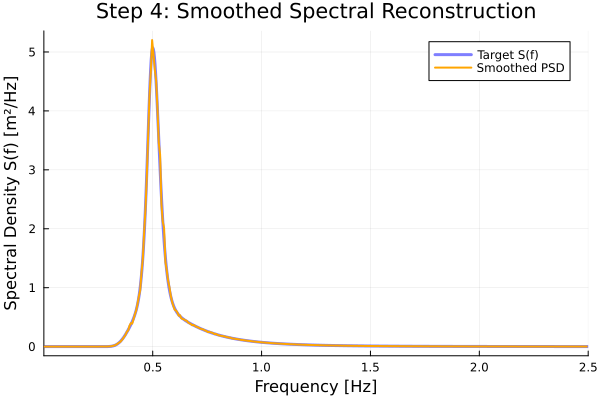

In [5]:
# Apply local averaging to smooth the raw FFT spectrum
f_smooth, psd_smooth = averaged_psd(fHalf, psd)

# Overlay smoothed result with target
p4 = plot(f_cont, S_cont, label="Target S(f)", lw=3, color=:blue, alpha=0.5)
plot!(p4, f_smooth, psd_smooth, color=:orange, label="Smoothed PSD", lw=2)
title!("Step 4: Smoothed Spectral Reconstruction")
xlabel!("Frequency [Hz]")
ylabel!("Spectral Density S(f) [m²/Hz]")
xlims!(get_fmin(spec), get_fmax(spec))

## Step 5: Validate Spectral Properties
Now we check that key statistical properties of the reconstructed spectrum match the target. Three tests confirm:

1. **Total Energy (Variance):** The integral of the PSD equals the target variance
$$\int_0^{\infty} S(f) \, df = \frac{H_s^2}{16}$$

2. **Energy in Peak Region:** Energy concentrated around the peak frequency validates spectral shape
$$\int_{0.8 f_p}^{1.2 f_p} S_{\text{sim}}(f) \, df \approx \int_{0.8 f_p}^{1.2 f_p} S_{\text{target}}(f) \, df$$

3. **Peak Spectral Density:** The maximum smoothed PSD matches the target peak
$$S_{\text{max}}(\text{sim}) \approx S_{\text{max}}(\text{target})$$

In [6]:
# ========================================================================
# TEST 1: Total Energy Validation
# ========================================================================
# The integral of the one-sided PSD should equal the target variance.
# Variance of sea surface elevation η is related to Hs by: var(η) = Hs²/16
#
# Discrete integration: ∫ S(f) df ≈ Σ psd(f_i) * Δf ≈ Σ psd * (fs/N)

@test sum(psd .* fs/N) ≈ Hs_target^2 / 16 rtol=1e-2

println("✓ Test 1 passed: Total spectral energy matches target variance")

✓ Test 1 passed: Total spectral energy matches target variance


In [7]:
# ========================================================================
# TEST 2: Energy in Peak Region Validation
# ========================================================================
# Check that the energy in the peak frequency band (±20% around fp) 
# is preserved between the target and simulated spectra.
# This validates that the spectral shape is correctly reproduced.
#
# Peak frequency: fp = 1 / Tp

# Energy integrated over [0.8*fp, 1.2*fp] in the simulated FFT
mask_sim = (fHalf .> 0.8/Tp_target) .& (fHalf .< 1.2/Tp_target)
energy_sim = sum(psd[mask_sim]) * (fHalf[2] - fHalf[1])

# Energy integrated over [0.8*fp, 1.2*fp] in the target spectrum
mask_target = (f_cont .> 0.8/Tp_target) .& (f_cont .< 1.2/Tp_target)
energy_target = sum(S_cont[mask_target]) * (f_cont[2] - f_cont[1])

@test energy_sim ≈ energy_target rtol=0.05

println("✓ Test 2 passed: Energy in peak region matches target")

✓ Test 2 passed: Energy in peak region matches target


In [8]:
# ========================================================================
# TEST 3: Peak Spectral Density Validation
# ========================================================================
# Verify that the maximum of the smoothed reconstructed spectrum 
# matches the target peak spectral density S_max(fp).
# This is a direct check of the model's representation quality.

S_max_target = ContinuousSpectrums.get_density(spec, 1.0/get_Tp(spec))
S_max_sim = maximum(psd_smooth)

@test S_max_sim ≈ S_max_target rtol=0.15

println("✓ Test 3 passed: Peak spectral density matches target")
println("\nAll validation tests passed! FFT reconstruction is successful.")

✓ Test 3 passed: Peak spectral density matches target

All validation tests passed! FFT reconstruction is successful.


## Summary

This tutorial demonstrated the complete signal-to-spectrum cycle:

| Stage | Purpose | Input | Output |
|-------|---------|-------|--------|
| **1. Spectrum Model** | Define statistical target | `Hs`, `Tp`, spectrum type | Continuous `S(f)`, discretized into components |
| **2. Signal Synthesis** | Generate time realization | Discrete spectrum, random phases | Time series `η(t)` |
| **3. FFT Reconstruction** | Recover frequency content | Time series, sampling rate | Raw PSD (noisy) |
| **4. Smoothing** | Reduce estimation noise | Raw PSD | Smoothed PSD (clean) |
| **5. Validation** | Confirm fidelity | Target & reconstructed spectra | Energy, peak, shape match |

**Key Takeaways:**
- The WaveSpec.Signal module automates synthesis: amplitude, frequency, phase, and dispersion are computed internally
- FFT recovers the spectral structure, but requires smoothing and careful handling of aliasing (Nyquist)
- Validation tests ensure the simulated realization is statistically consistent with the target model
- This workflow is the foundation for ocean wave simulation and climate/engineering analysis

**Further Exploration:**
- Vary `Hs` and `Tp` to see how peak frequency and bandwidth change
- Try different spectrum models (Bretschneider, Ochi-Hubble) to see spectral shapes
- Adjust smoothing parameters to trade resolution for variance reduction
- Extend to 2D/3D grids and velocity fields using `WaveSpec.AiryWaves`